## Universidad Autónoma de Aguascalientes
## Departamento: Ciencias de la Computación
## Carrera: Ingeniería en Computación Inteligente
## Curso: Machine y Deep Learning
## Maestro: Dr. Francisco Javier Luna Rosas
## Alumno: Guillermo González Lara (237864)
## Semestre: Enero - Junio del 2026

## Proyecto: Generación de Rostros mediante Redes Generativas Adversarias (GANs)

Este proyecto implementa una arquitectura DCGAN (Deep Convolutional Generative Adversarial Network) construida desde cero. El objetivo principal es entrenar un modelo generativo capaz de sintetizar imágenes realistas del rostro capturado en el dataset propio, logrando engañar a la red discriminadora a través del entrenamiento continuo en un juego de suma cero.

**Flujo de la Arquitectura:**
* **Dataset Propio:** Captura automatizada de fotografías faciales en tiempo real mediante un script de OpenCV integrado en el notebook.
* **Red Generadora ($G$):** Recibe un vector de ruido aleatorio (espacio latente $z$) y proyecta una imagen generada (fake) con dimensiones estandarizadas mediante capas `Conv2DTranspose`.
* **Red Discriminadora ($D$):** Recibe de forma alternada lotes de imágenes reales del dataset y lotes de imágenes sintéticas del Generador. Determina la probabilidad de que la imagen de entrada sea auténtica.
* **Optimización Adversaria:** El error (loss) del discriminador castiga su incapacidad para clasificar correctamente imágenes reales vs. falsas. El error del generador castiga su incapacidad para que sus imágenes sean clasificadas como "reales" por el discriminador.

In [1]:
import os
import time
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from pathlib import Path
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, utils

# Configuración de dispositivo (GPU si está disponible)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Trabajando en: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

    
DATASET_DIR    = Path('dataset_rostros_pt')  
IMG_SIZE   = 128    

Trabajando en: cuda
GPU: NVIDIA GeForce RTX 5060 Laptop GPU


═══════════════════════════════════════════════════════
  DATASET EXISTENTE
═══════════════════════════════════════════════════════
  Carpeta           : dataset_rostros_pt
  Imágenes halladas : 700
  Último índice     : img_699.jpg
  Próxima captura   : img_700.jpg
═══════════════════════════════════════════════════════

🎥  Cámara abierta. Meta de fotos adicionales: 5000
   ESPACIO=capturar  │  Q=terminar
  ⏹  Sesión terminada. Fotos nuevas: 0

═══════════════════════════════════════════════════════
  DATASET TOTAL  : 700 imágenes
  Fotos nuevas   : 0
  Rango de índices: img_0 … img_699
═══════════════════════════════════════════════════════


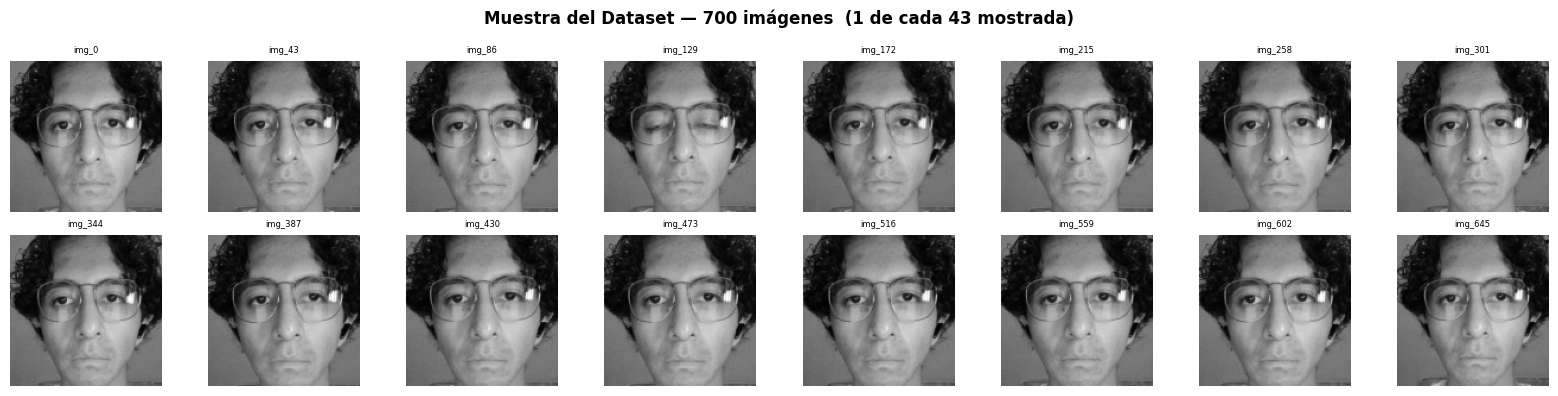

Mosaico guardado como muestra_dataset_crudo.png


In [2]:
# ═══════════════════════════════════════════════════════════════════════
#  CELDA 2 — Captura opcional de fotos adicionales
#
#  El dataset principal (dataset_rostros_pt, 3000 imgs) ya está cargado.
#  Esta celda permite AMPLIAR el dataset si se desea: las nuevas fotos
#  se guardan en la misma carpeta con el mismo esquema  img_N.jpg
#  continuando desde el índice más alto existente.
#
#  Controles:
#    ESPACIO = capturar foto (solo si hay rostro detectado)
#    Q       = terminar sesión
# ═══════════════════════════════════════════════════════════════════════

# ── Utilidad: ordenar img_N numéricamente ─────────────────────────────
def _indice(p):
    """Extrae el entero N de un Path cuyo stem es 'img_N'."""
    try:
        return int(p.stem.split('_')[1])
    except (IndexError, ValueError):
        return -1

# ── Detectar el siguiente índice libre ────────────────────────────────
imgs_existentes = [p for p in DATASET_DIR.iterdir()
                   if p.suffix.lower() in ('.jpg', '.jpeg', '.png')
                   and p.stem.startswith('img_')]
siguiente_idx = max((_indice(p) for p in imgs_existentes), default=-1) + 1

print('═' * 55)
print('  DATASET EXISTENTE')
print('═' * 55)
print(f'  Carpeta           : {DATASET_DIR}')
print(f'  Imágenes halladas : {len(imgs_existentes)}')
print(f'  Último índice     : img_{siguiente_idx - 1}.jpg')
print(f'  Próxima captura   : img_{siguiente_idx}.jpg')
print('═' * 55)

# ── Sesión de captura ─────────────────────────────────────────────────
META_ADICIONALES = 5000   # Cuántas fotos más quieres tomar (0 = solo revisar)

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

contador       = siguiente_idx
nuevas         = 0
ultima_captura = 0

cap = cv2.VideoCapture(0)
if not cap.isOpened():
    print('\n⚠  Cámara no disponible — se omite la captura.')
    print('   El dataset existente se usará tal cual.')
else:
    print(f'\n🎥  Cámara abierta. Meta de fotos adicionales: {META_ADICIONALES}')
    print('   ESPACIO=capturar  │  Q=terminar')

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        gray    = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        gray_eq = cv2.equalizeHist(gray)
        faces   = face_cascade.detectMultiScale(
            gray_eq, scaleFactor=1.15, minNeighbors=6, minSize=(80, 80))

        display     = frame.copy()
        rostro_crop = None

        for (x, y, w, h) in faces:
            margin = int(0.10 * w)
            x1 = max(0, x - margin)
            y1 = max(0, y - margin)
            x2 = min(frame.shape[1], x + w + margin)
            y2 = min(frame.shape[0], y + h + margin)
            cv2.rectangle(display, (x1, y1), (x2, y2), (0, 230, 100), 2)
            crop        = gray_eq[y1:y2, x1:x2]
            rostro_crop = cv2.resize(crop, (IMG_SIZE, IMG_SIZE),
                                     interpolation=cv2.INTER_AREA)
            break

        # ── HUD ──────────────────────────────────────────────────────
        estado    = '✓ Rostro detectado' if rostro_crop is not None else '— Sin rostro'
        color_hud = (0, 230, 100) if rostro_crop is not None else (0, 80, 220)
        pct       = min(100, int(nuevas / max(META_ADICIONALES, 1) * 100))
        barra     = '█' * (pct // 4) + '░' * (25 - pct // 4)

        cv2.putText(display, estado,
                    (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.65, color_hud, 2)
        cv2.putText(display, f'Nueva: img_{contador}.jpg  [{nuevas}/{META_ADICIONALES}]',
                    (10, 60), cv2.FONT_HERSHEY_SIMPLEX, 0.60, (255, 255, 255), 2)
        cv2.putText(display, f'[{barra}] {pct}%',
                    (10, 90), cv2.FONT_HERSHEY_SIMPLEX, 0.50, (200, 200, 200), 1)
        cv2.putText(display, 'ESPACIO=capturar  Q=salir',
                    (10, display.shape[0] - 15),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, (180, 180, 180), 1)

        if rostro_crop is not None:
            mini     = cv2.resize(rostro_crop, (80, 80))
            mini_bgr = cv2.cvtColor(mini, cv2.COLOR_GRAY2BGR)
            display[10:90, display.shape[1]-90:display.shape[1]-10] = mini_bgr

        cv2.imshow('GAN — Ampliar Dataset', display)
        tecla = cv2.waitKey(1) & 0xFF
        ahora = time.time()

        if tecla == ord(' ') and rostro_crop is not None and (ahora - ultima_captura) > 0.3:
            # Nombre exactamente igual al esquema existente: img_N.jpg
            ruta_img = DATASET_DIR / f'img_{contador}.jpg'
            cv2.imwrite(str(ruta_img), rostro_crop)
            contador       += 1
            nuevas         += 1
            ultima_captura  = ahora
            if nuevas % 25 == 0:
                print(f'  📷  {nuevas}/{META_ADICIONALES} fotos nuevas guardadas.')
            if nuevas >= META_ADICIONALES:
                print(f'  ✅  Meta de {META_ADICIONALES} fotos adicionales alcanzada.')
                break

        elif tecla == ord('q') or tecla == 27:
            print(f'  ⏹  Sesión terminada. Fotos nuevas: {nuevas}')
            break

    cap.release()
    cv2.destroyAllWindows()

# ── Resumen y mosaico del dataset completo ────────────────────────────
todas_las_fotos = sorted(
    [p for p in DATASET_DIR.iterdir()
     if p.suffix.lower() in ('.jpg', '.jpeg', '.png')
     and p.stem.startswith('img_')],
    key=_indice
)

print()
print('═' * 55)
print(f'  DATASET TOTAL  : {len(todas_las_fotos)} imágenes')
print(f'  Fotos nuevas   : {nuevas}')
print(f'  Rango de índices: img_0 … img_{_indice(todas_las_fotos[-1])}')
print('═' * 55)

# Mosaico espaciado uniformemente (16 muestras representativas)
paso         = max(1, len(todas_las_fotos) // 16)
muestra_paths = todas_las_fotos[::paso][:16]

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
fig.suptitle(f'Muestra del Dataset — {len(todas_las_fotos)} imágenes  '
             f'(1 de cada {paso} mostrada)',
             fontsize=12, fontweight='bold')
for ax, p in zip(axes.flat, muestra_paths):
    img = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
    ax.imshow(img, cmap='gray')
    ax.set_title(p.stem, fontsize=6)
    ax.axis('off')
for ax in axes.flat[len(muestra_paths):]:
    ax.axis('off')
plt.tight_layout()
plt.savefig('muestra_dataset_crudo.png', dpi=110, bbox_inches='tight')
plt.show()
print('Mosaico guardado como muestra_dataset_crudo.png')

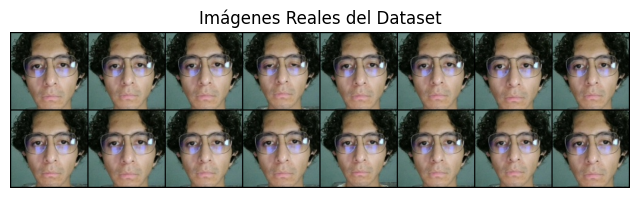

In [3]:
class FaceDataset(Dataset):
    def __init__(self, folder, transform=None):
        self.folder = folder
        self.images = [f for f in os.listdir(folder) if f.endswith('.jpg')]
        self.transform = transform

    def __len__(self): return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.folder, self.images[idx])
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        if self.transform: image = self.transform(image)
        return image

# Transformaciones estándar para GANs: Normalizar a [-1, 1]
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

dataset = FaceDataset(DATASET_DIR, transform=transform)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

# Visualización de verificación
real_batch = next(iter(dataloader))
plt.figure(figsize=(8,8))
plt.axis("off")
plt.title("Imágenes Reales del Dataset")
plt.imshow(np.transpose(utils.make_grid(real_batch[:16], padding=2, normalize=True).cpu(),(1,2,0)))
plt.show()

In [4]:
# Hiperparámetros de arquitectura
nz = 100  # Tamaño del vector de ruido
ngf = 64  # Tamaño de feature maps en generador
ndf = 64  # Tamaño de feature maps en discriminador


class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            # Entrada: Z (100) -> 4 x 4
            nn.ConvTranspose2d(nz, ngf * 16, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 16),
            nn.ReLU(True),
            # (ngf*16) x 4 x 4 -> 8 x 8
            nn.ConvTranspose2d(ngf * 16, ngf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),
            # (ngf*8) x 8 x 8 -> 16 x 16
            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            # (ngf*4) x 16 x 16 -> 32 x 32
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            # (ngf*2) x 32 x 32 -> 64 x 64
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            # (ngf) x 64 x 64 -> 128 x 128 <-- Capa adicional
            nn.ConvTranspose2d(ngf, 3, 4, 2, 1, bias=False),
            nn.Tanh(),
            # Salida: 3 x 128 x 128
        )

    def forward(self, input):
        return self.main(input)

from torch.nn.utils import spectral_norm

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            # Entrada: 3 x 128 x 128 -> 64 x 64 <-- Capa adicional
            spectral_norm(nn.Conv2d(3, ndf, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),
            # (ndf) x 64 x 64 -> 32 x 32
            spectral_norm(nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False)),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # (ndf*2) x 32 x 32 -> 16 x 16
            spectral_norm(nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False)),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # (ndf*4) x 16 x 16 -> 8 x 8
            spectral_norm(nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False)),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),
            # (ndf*8) x 8 x 8 -> 4 x 4
            spectral_norm(nn.Conv2d(ndf * 8, ndf * 16, 4, 2, 1, bias=False)),
            nn.BatchNorm2d(ndf * 16),
            nn.LeakyReLU(0.2, inplace=True),
            # Capa de salida: 4 x 4 -> 1 x 1
            spectral_norm(nn.Conv2d(ndf * 16, 1, 4, 1, 0, bias=False)),
            nn.Sigmoid(),
        )

    def forward(self, input):
        return self.main(input)

# Inicialización de pesos recomendada por el paper de DCGAN
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find("Conv") != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find("BatchNorm") != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


netG = Generator().to(device)
netG.apply(weights_init)
netD = Discriminator().to(device)
netD.apply(weights_init)

Discriminator(
  (main): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (9): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
    (11): Conv2d(512, 1024, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (12): BatchNorm2d(1024, eps=1e-05

Iniciando Entrenamiento...
Época [0/500]
  ├─ Loss D: 0.0000 | Loss G: 37.2939
  ├─ D(x): 1.0000 (Ideal: ~0.5 a 0.9) -> Confianza en Reales
  └─ D(G(z)): 0.0000 (Ideal: ~0.5) -> Capacidad de Engaño


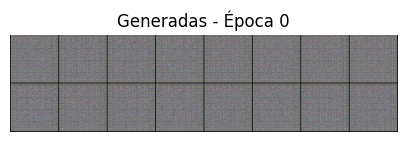

Época [10/500]
  ├─ Loss D: 0.0013 | Loss G: 8.3660
  ├─ D(x): 0.9998 (Ideal: ~0.5 a 0.9) -> Confianza en Reales
  └─ D(G(z)): 0.0011 (Ideal: ~0.5) -> Capacidad de Engaño


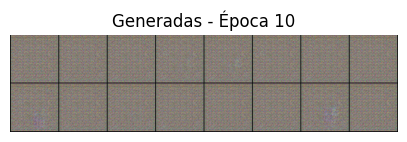

Época [20/500]
  ├─ Loss D: 4.2961 | Loss G: 4.3441
  ├─ D(x): 0.0153 (Ideal: ~0.5 a 0.9) -> Confianza en Reales
  └─ D(G(z)): 0.0004 (Ideal: ~0.5) -> Capacidad de Engaño


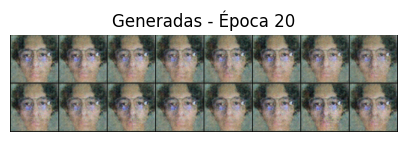

Época [30/500]
  ├─ Loss D: 0.2686 | Loss G: 3.2385
  ├─ D(x): 0.9456 (Ideal: ~0.5 a 0.9) -> Confianza en Reales
  └─ D(G(z)): 0.1879 (Ideal: ~0.5) -> Capacidad de Engaño


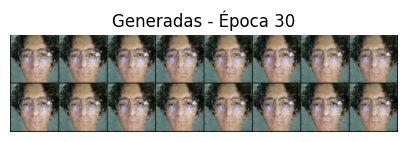

Época [40/500]
  ├─ Loss D: 1.7436 | Loss G: 2.6296
  ├─ D(x): 0.2584 (Ideal: ~0.5 a 0.9) -> Confianza en Reales
  └─ D(G(z)): 0.0019 (Ideal: ~0.5) -> Capacidad de Engaño


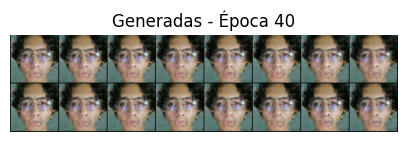

Época [50/500]
  ├─ Loss D: 0.1490 | Loss G: 11.0054
  ├─ D(x): 0.8867 (Ideal: ~0.5 a 0.9) -> Confianza en Reales
  └─ D(G(z)): 0.0000 (Ideal: ~0.5) -> Capacidad de Engaño


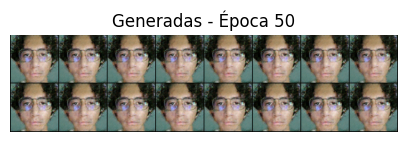

Época [60/500]
  ├─ Loss D: 0.0741 | Loss G: 4.3238
  ├─ D(x): 0.9459 (Ideal: ~0.5 a 0.9) -> Confianza en Reales
  └─ D(G(z)): 0.0165 (Ideal: ~0.5) -> Capacidad de Engaño


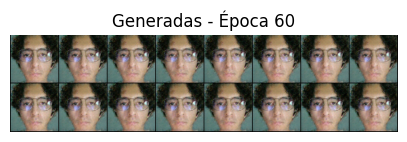

Época [70/500]
  ├─ Loss D: 0.0397 | Loss G: 5.4397
  ├─ D(x): 0.9953 (Ideal: ~0.5 a 0.9) -> Confianza en Reales
  └─ D(G(z)): 0.0343 (Ideal: ~0.5) -> Capacidad de Engaño


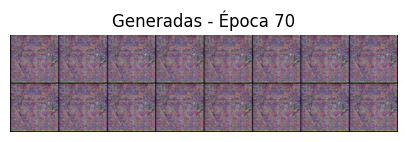

Época [80/500]
  ├─ Loss D: 0.1291 | Loss G: 4.2657
  ├─ D(x): 0.9465 (Ideal: ~0.5 a 0.9) -> Confianza en Reales
  └─ D(G(z)): 0.0705 (Ideal: ~0.5) -> Capacidad de Engaño


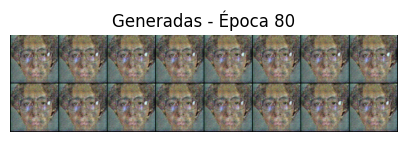

Época [90/500]
  ├─ Loss D: 0.0013 | Loss G: 7.8002
  ├─ D(x): 0.9992 (Ideal: ~0.5 a 0.9) -> Confianza en Reales
  └─ D(G(z)): 0.0005 (Ideal: ~0.5) -> Capacidad de Engaño


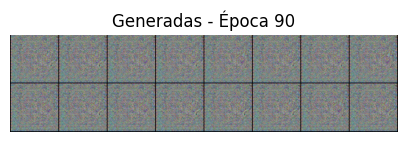

Época [100/500]
  ├─ Loss D: 0.0011 | Loss G: 7.5855
  ├─ D(x): 0.9996 (Ideal: ~0.5 a 0.9) -> Confianza en Reales
  └─ D(G(z)): 0.0007 (Ideal: ~0.5) -> Capacidad de Engaño


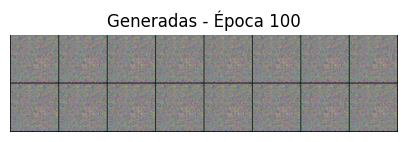

Época [110/500]
  ├─ Loss D: 0.0003 | Loss G: 10.1141
  ├─ D(x): 0.9998 (Ideal: ~0.5 a 0.9) -> Confianza en Reales
  └─ D(G(z)): 0.0000 (Ideal: ~0.5) -> Capacidad de Engaño


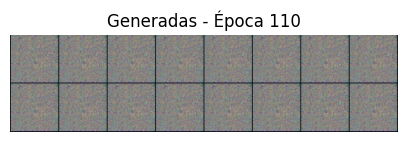

Época [120/500]
  ├─ Loss D: 0.0001 | Loss G: 10.8789
  ├─ D(x): 0.9999 (Ideal: ~0.5 a 0.9) -> Confianza en Reales
  └─ D(G(z)): 0.0000 (Ideal: ~0.5) -> Capacidad de Engaño


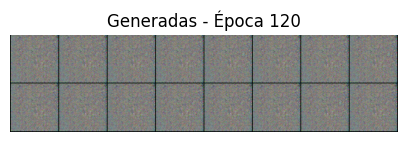

Época [130/500]
  ├─ Loss D: 0.0002 | Loss G: 9.4954
  ├─ D(x): 0.9999 (Ideal: ~0.5 a 0.9) -> Confianza en Reales
  └─ D(G(z)): 0.0001 (Ideal: ~0.5) -> Capacidad de Engaño


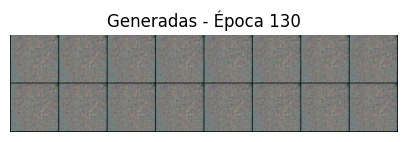

Época [140/500]
  ├─ Loss D: 0.0003 | Loss G: 8.6496
  ├─ D(x): 0.9999 (Ideal: ~0.5 a 0.9) -> Confianza en Reales
  └─ D(G(z)): 0.0002 (Ideal: ~0.5) -> Capacidad de Engaño


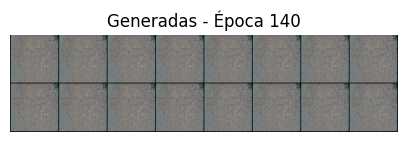

Época [150/500]
  ├─ Loss D: 100.0000 | Loss G: 0.0000
  ├─ D(x): 1.0000 (Ideal: ~0.5 a 0.9) -> Confianza en Reales
  └─ D(G(z)): 1.0000 (Ideal: ~0.5) -> Capacidad de Engaño


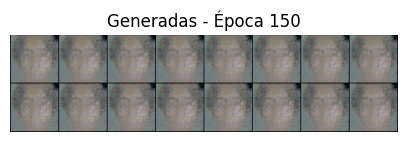

Época [160/500]
  ├─ Loss D: 100.0000 | Loss G: 0.0000
  ├─ D(x): 1.0000 (Ideal: ~0.5 a 0.9) -> Confianza en Reales
  └─ D(G(z)): 1.0000 (Ideal: ~0.5) -> Capacidad de Engaño


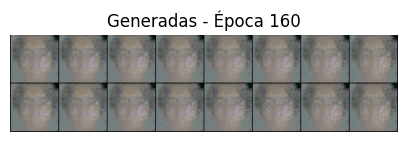

Época [170/500]
  ├─ Loss D: 100.0000 | Loss G: 0.0000
  ├─ D(x): 1.0000 (Ideal: ~0.5 a 0.9) -> Confianza en Reales
  └─ D(G(z)): 1.0000 (Ideal: ~0.5) -> Capacidad de Engaño


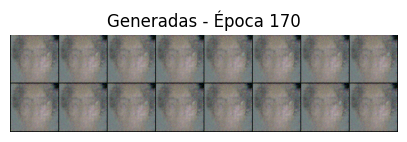

Época [180/500]
  ├─ Loss D: 100.0000 | Loss G: 0.0000
  ├─ D(x): 1.0000 (Ideal: ~0.5 a 0.9) -> Confianza en Reales
  └─ D(G(z)): 1.0000 (Ideal: ~0.5) -> Capacidad de Engaño


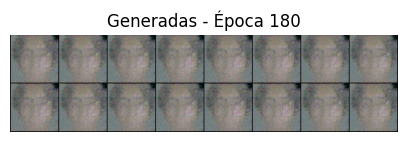

Época [190/500]
  ├─ Loss D: 100.0000 | Loss G: 0.0000
  ├─ D(x): 1.0000 (Ideal: ~0.5 a 0.9) -> Confianza en Reales
  └─ D(G(z)): 1.0000 (Ideal: ~0.5) -> Capacidad de Engaño


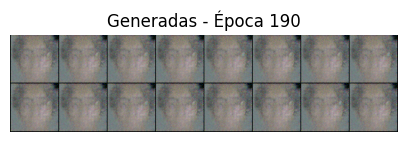

Época [200/500]
  ├─ Loss D: 100.0000 | Loss G: 0.0000
  ├─ D(x): 1.0000 (Ideal: ~0.5 a 0.9) -> Confianza en Reales
  └─ D(G(z)): 1.0000 (Ideal: ~0.5) -> Capacidad de Engaño


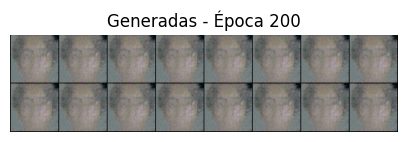

Época [210/500]
  ├─ Loss D: 100.0000 | Loss G: 0.0000
  ├─ D(x): 1.0000 (Ideal: ~0.5 a 0.9) -> Confianza en Reales
  └─ D(G(z)): 1.0000 (Ideal: ~0.5) -> Capacidad de Engaño


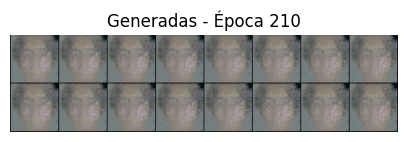

Época [220/500]
  ├─ Loss D: 100.0000 | Loss G: 0.0000
  ├─ D(x): 1.0000 (Ideal: ~0.5 a 0.9) -> Confianza en Reales
  └─ D(G(z)): 1.0000 (Ideal: ~0.5) -> Capacidad de Engaño


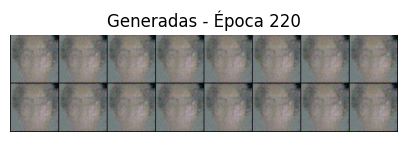

KeyboardInterrupt: 

In [5]:
criterion = nn.BCELoss()
# Vector de ruido fijo para visualizar la evolución exacta de las mismas imágenes
fixed_noise = torch.randn(64, nz, 1, 1, device=device)

optimizerD = optim.Adam(netD.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=0.0002, betas=(0.5, 0.999))

num_epochs = 500
print("Iniciando Entrenamiento...")

for epoch in range(num_epochs):
    for i, data in enumerate(dataloader, 0):
        # -----------------------------------------------------------
        # (1) Actualizar Discriminador: maximizar log(D(x)) + log(1 - D(G(z)))
        # -----------------------------------------------------------
        netD.zero_grad()
        real_cpu = data.to(device)
        b_size = real_cpu.size(0)
        label = torch.full((b_size,), 1.0, dtype=torch.float, device=device)
        
        # Pase real: Guardamos la predicción en 'output_real'
        output_real = netD(real_cpu).view(-1)
        errD_real = criterion(output_real, label)
        errD_real.backward()

        # Pase falso: Generamos imágenes y guardamos la predicción en 'output_fake'
        noise = torch.randn(b_size, nz, 1, 1, device=device)
        fake = netG(noise)
        label.fill_(0.0)
        output_fake = netD(fake.detach()).view(-1)
        errD_fake = criterion(output_fake, label)
        errD_fake.backward()
        optimizerD.step()

        # -----------------------------------------------------------
        # (2) Actualizar Generador: maximizar log(D(G(z)))
        # -----------------------------------------------------------
        netG.zero_grad()
        label.fill_(1.0)  # Las etiquetas falsas son reales para el coste del generador
        # Usamos una nueva variable para la salida del generador evaluada por D
        output_gen = netD(fake).view(-1)
        errG = criterion(output_gen, label)
        errG.backward()
        optimizerG.step()

    # Progreso visual y comprobación de métricas al final de la época
    # (Evaluado sobre el último lote procesado en esta época)
    if epoch % 10 == 0 or epoch == num_epochs - 1:
        # Calcular la salida media del discriminador
        D_x = output_real.mean().item() 
        D_G_z = output_fake.mean().item()
        
        print(f'Época [{epoch}/{num_epochs}]')
        print(f'  ├─ Loss D: {errD_real.item()+errD_fake.item():.4f} | Loss G: {errG.item():.4f}')
        print(f'  ├─ D(x): {D_x:.4f} (Ideal: ~0.5 a 0.9) -> Confianza en Reales')
        print(f'  └─ D(G(z)): {D_G_z:.4f} (Ideal: ~0.5) -> Capacidad de Engaño')
        
        if 0.4 <= D_G_z <= 0.6:
            print("  ★ ¡ESTADO ÓPTIMO!: El generador está logrando engañar al discriminador.")
            
        with torch.no_grad():
            fake_display = netG(fixed_noise).detach().cpu()
        plt.figure(figsize=(5, 5))
        plt.axis("off")
        plt.title(f"Generadas - Época {epoch}")
        plt.imshow(np.transpose(utils.make_grid(fake_display[:16], padding=2, normalize=True), (1, 2, 0)))
        plt.show()

In [ ]:
# Guardamos los pesos en formato .pth (estándar de PyTorch)
torch.save(netG.state_dict(), 'generador_v2.pth')
torch.save(netD.state_dict(), 'discriminador_v2.pth')
print("Modelos guardados exitosamente.")

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
#  CELDA 12 — Generador interactivo en tiempo real con OpenCV
# ═══════════════════════════════════════════════════════════════════════

# Ponemos ambas redes en modo evaluación (desactiva Dropout y fija BatchNorm)
netG.eval()
netD.eval()

ZOOM    = 8     # Factor de escala para la ventana (64×8 = 512 px)
n_gards = 0

def tensor_a_bgr(tensor_img):
    """Convierte un tensor (1, 3, H, W) en rango [-1, 1] a una imagen BGR ampliada para OpenCV."""
    # Extraemos el tensor de la GPU, quitamos la dimensión batch y reordenamos canales a (H, W, C)
    arr = tensor_img.cpu().squeeze().permute(1, 2, 0).numpy()
    # Desnormalizamos de [-1, 1] a [0, 1]
    arr = np.clip(arr * 0.5 + 0.5, 0.0, 1.0)
    # Convertimos a enteros uint8 [0, 255]
    arr8 = (arr * 255).astype(np.uint8)
    # Convertimos de RGB (modelo PyTorch) a BGR (modelo OpenCV)
    arr_bgr = cv2.cvtColor(arr8, cv2.COLOR_RGB2BGR)
    # Redimensionamos usando el vecino más cercano para mantener la nitidez de los píxeles generados
    grande = cv2.resize(arr_bgr, (IMG_SIZE * ZOOM, IMG_SIZE * ZOOM), interpolation=cv2.INTER_NEAREST)
    return grande

print('▶  Iniciando sesión interactiva de Síntesis Facial...')
print('   ESPACIO=Nuevo rostro (z aleatorio) │ I=Interpolar (LERP) │ S=Guardar foto │ Q=Salir')

# Generamos los vectores de ruido iniciales con la forma esperada por el generador (1, nz, 1, 1)
z_actual  = torch.randn(1, nz, 1, 1, device=device)
z_destino = torch.randn(1, nz, 1, 1, device=device)
modo_lerp = False
alpha_l   = 0.0
paso_lerp = 0.02  # Velocidad de la transición suave

with torch.no_grad():
    while True:
        # ── 1. Calcular el vector latente z de este fotograma ─────────
        if modo_lerp:
            # Interpolación Lineal (LERP) entre dos puntos del espacio latente
            z_uso   = (1.0 - alpha_l) * z_actual + alpha_l * z_destino
            alpha_l += paso_lerp
            if alpha_l >= 1.0:
                z_actual  = z_destino.clone()
                z_destino = torch.randn(1, nz, 1, 1, device=device)
                alpha_l   = 0.0
        else:
            z_uso = z_actual

        # ── 2. Generar imagen sintética y evaluar con el Crítico ──────
        img_gen = netG(z_uso)
        # Evaluamos qué tan real le parece al discriminador
        score   = netD(img_gen).item()
        frame   = tensor_a_bgr(img_gen)

        # ── 3. Dibujar HUD y Barra de Engaño en pantalla ──────────────
        alto, ancho, _ = frame.shape
        barra_w = int(score * (ancho - 20))
        # El color va de rojo (descubierto/falso) a verde (éxito/engañado)
        color_b = (0, int(255 * score), int(255 * (1.0 - score))) # Formato BGR
        
        # Relleno de la barra
        cv2.rectangle(frame, (10, alto - 30), (10 + barra_w, alto - 10), color_b, -1)
        # Contorno de la barra
        cv2.rectangle(frame, (10, alto - 30), (ancho - 10, alto - 10), (80, 80, 80), 1)

        modo_str = 'INTERPOLANDO' if modo_lerp else 'ESTATICO'
        # Textos informativos superpuestos con sombra para legibilidad
        cv2.putText(frame, f'D(G(z)): {score:.3f} [{modo_str}]', (12, 35), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,0,0), 3)
        cv2.putText(frame, f'D(G(z)): {score:.3f} [{modo_str}]', (12, 35), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,255,255), 1)
        
        cv2.putText(frame, 'SPC=Aleatorio  I=Transicion  S=Capturar  Q=Salir', (12, 70), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (200, 200, 200), 1)
        cv2.putText(frame, f'Rostros Guardados: {n_gards}', (12, 95), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 255, 255), 1)

        # ── 4. Renderizar ventana y capturar teclado ──────────────────
        cv2.imshow('GAN - Sintesis Facial en Vivo', frame)
        tecla = cv2.waitKey(30) & 0xFF

        if tecla == ord('q') or tecla == 27: # 'q' o ESC para salir
            break
        elif tecla == ord(' '):
            z_actual  = torch.randn(1, nz, 1, 1, device=device)
            modo_lerp = False
            alpha_l   = 0.0
        elif tecla == ord('i'):
            modo_lerp = not modo_lerp
            if modo_lerp:
                z_destino = torch.randn(1, nz, 1, 1, device=device)
                alpha_l   = 0.0
        elif tecla == ord('s'):
            ruta_g = f'rostro_sintetico_{n_gards:03d}.png'
            cv2.imwrite(ruta_g, frame)
            n_gards += 1
            print(f'   💾 Guardado exitosamente: {ruta_g} (Puntuacion de Engaño: {score:.3f})')

cv2.destroyAllWindows()
print(f'\n✅ Inferencia finalizada. Se exportaron {n_gards} rostros sintéticos al directorio local.')

## Referencias
- Paszke, A., et al. (2019). PyTorch: An Imperative Style, High-Performance Deep Learning Library.
- Goodfellow, I. (2016). NIPS 2016 Tutorial: Generative Adversarial Networks.
- Documentación oficial de PyTorch: https://pytorch.org/tutorials/beginner/dcgan_faces_tutorial.html